In [47]:
# --- Bloco de Importação de Bibliotecas ---
import os # Para interagir com o sistema operacional (ler arquivos de uma pasta).
import pandas as pd # Para manipulação e análise de dados (usando DataFrames).
import numpy as np # Para operações matemáticas e numéricas.
import matplotlib.pyplot as plt # Para criar gráficos e visualizações.
import sys

# --- Bloco de Definição de Constantes e Parâmetros ---) 
n = 1 # Define o coeficiente 'n' (relacionado à velocidade de grupo da onda).
g = 9.81 # Define a aceleração da gravidade.
rho = 1025 # Define a densidade da água.

# --- Bloco de Configuração Inicial ---
pasta_altura = "C:\\Diretorio Delft3D\\Jacone\\Resultados\\Altura" # Define o caminho da pasta contendo os arquivos CSV de altura.
resultados = [] # Cria uma lista vazia para armazenar os resultados da temsão de radiação de cada arquivo.

""" a pasta é o caminho onde estão os arquivos csv, que são os resultados do Delft3D."""

' a pasta é o caminho onde estão os arquivos csv, que são os resultados do Delft3D.'

In [75]:
# --- Bloco Principal: Loop para Processar Cada Arquivo ---
for arquivo in os.listdir(pasta_altura): # Itera sobre os arquivos na pasta e atribui a arquivo o nome do arquivo
    if arquivo.endswith(".csv"): # Verifica se o arquivo é um CSV.
        caminho_arquivo = os.path.join(pasta_altura, arquivo) # Junta o caminho da pasta com o nome do arquivo. # aqui caminho_arquivo ja junta a pasta e o arquivo
        df = pd.read_csv(caminho_arquivo, sep=";", header=0) # Lê o arquivo CSV para um DataFrame do pandas. # df é um datafram

             #tratamento dos dados de coordenadas dos arquivos de altura
        primeiro_valorX = df["x coordinate"].iloc[1] # obtém o valor da coluna "x coordinate" na terceira linha (índice 2)
        x_coordinate_h = df["x coordinate"] - primeiro_valorX # ajusta os valores da coluna "x coordinate" subtraindo o primeiro valor de cada linha
        
        primeiro_valorY = df["y coordinate"].iloc[1] # obtém o valor da coluna "y coordinate" na terceira linha (índice 2)
        y_coordinate_h = df["y coordinate"] - primeiro_valorY # ajusta os valores da coluna "y coordinate" subtraindo o primeiro valor de cada linha
        
        comprimento_sessao_h = (x_coordinate_h**2 + y_coordinate_h**2)**0.5 # Calcula o comprimento da sessão. 
        

        # ----- Sub-bloco: Identificação da velocidade máxima de cada arquivo de altura e endereçar as tensões de radiação a ele -----
        pasta_velocidade = "C:\\Diretorio Delft3D\\Jacone\\Resultados\\Velocidade" # Define o caminho da pasta contendo os arquivos de velocidade.
        nome_base = arquivo[2:] #ignora o primeiro digito do arquivo de altura
        if arquivo.startswith("O"): 
            alpha = 0.2618 #em radianos
            nome_arquivo = "O" + nome_base # Cria o nome do arquivo de velocidade correspondente.
        elif arquivo.startswith("C"):
            alpha = 0.1222 #em radianos
            nome_arquivo = "C" + nome_base # Cria o nome do arquivo de velocidade correspondente.
        elif arquivo.startswith("L"):
            alpha= 0.1396 #em radianos
            nome_arquivo = "L" + nome_base # Cria o nome do arquivo de velocidade correspondente.
        else:
            sys.exit("Arquivo com nome inválido para determinar o ângulo alpha.")
         
        caminho_arquivo_vel = os.path.join(pasta_velocidade, nome_arquivo) # type: ignore # Junta o caminho da pasta de velocidade com o nome do arquivo de velocidade.
        df2 = pd.read_csv(caminho_arquivo_vel, sep=";", header=0, encoding='latin1') # Lê o arquivo CSV de velocidade para um DataFrame do pandas., ta lendo na pasta de velocidade
        df2["velocidade"] = pd.to_numeric(df2["velocidade"], errors='coerce')
        df2["x coordinate"] = pd.to_numeric(df2["x coordinate"], errors='coerce')
        df2["y coordinate"] = pd.to_numeric(df2["y coordinate"], errors='coerce')

           #tratamentos dos dados de coordenadas dos arquivos de velocidade
        primeiro_valorX_vel = df2["x coordinate"].iloc[2] # obtém o valor da coluna "x coordinate" na terceira linha (índice 2)
        x_coordinate_vel = df2["x coordinate"] - primeiro_valorX_vel # ajusta os valores da coluna "x coordinate" subtraindo o primeiro valor de cada linha
        
        primeiro_valorY_vel = df2["y coordinate"].iloc[2] # obtém o valor da coluna "y coordinate" na terceira linha (índice 2)
        y_coordinate_vel = df2["y coordinate"] - primeiro_valorY_vel # ajusta os valores da coluna "y coordinate" subtraindo o primeiro valor de cada linha
        
        comprimento_sessao_vel = (x_coordinate_vel**2 + y_coordinate_vel**2)**0.5 # Calcula o comprimento da sessão dos aquivos de velocidade.
        print(comprimento_sessao_vel)

        # ----- Sub-bloco: Identificação da velocidade máxima de cada arquivo de altura e endereçar as tensões de radiação a ele -----
        # Encontra a linha com o maior valor de Hs na segunda metade do DataFrame.
        max_velocidade = (df2["velocidade"].max())/0.854753153 # Encontra o valor máximo na coluna "velocity (m/s)" e divide pelo maior valor das velocidade
        max_hs = df.iloc[len(df)//2:].loc[lambda d: d["altura"].idxmax()] # Seleciona a linha com o valor máximo de "hsig wave height (m)" na segunda metade do DataFrame

        Hs = max_hs["altura"] # Extrai o valor de Hs da linha de valor máximo.
        x = max_hs["x coordinate"] # Extrai a coordenada x da linha de valor máximo.
    


        # --- Sub-bloco: Cálculos para o Ponto de Maior Hs ---
        #Usando a coluna "Hsig Wave Height (m)" 
        def tensao_radiacao(Hs, n, alpha): # Define a função para calcular a tensão de radiação Sxy.
            E = (1/8) * rho * g * Hs**2
            Sxy = E * n * np.sin(alpha) * np.cos(alpha)
            return Sxy
        
        Sxy = tensao_radiacao(Hs, n, alpha) # Calcula Sxy para o ponto de maior Hs.
       #print(f"Tensão de radiação Sxy no ponto de maior Hs: {Sxy:.3f} Pa") # Imprime o resultado.

        # --- Sub-bloco: Cálculos para o Antepenúltimo Ponto ---
        #selecionando o ponto do meio
        antepenultima_linha = df.iloc[-3] # Seleciona a antepenúltima linha do DataFrame. ANALISAR ESSA LINHA DEPOIS
        Hs2 = antepenultima_linha["altura"] # Extrai o valor de Hs da antepenúltima linha.
        x2 = antepenultima_linha["x coordinate"] # Extrai a coordenada x da antepenúltima linha.
        

        def tensao_radiacao2(Hs2, n, alpha): # Redefine a função de cálculo novamente.
            E = (1/8) * rho * g * Hs2**2
            Sxy2 = E * n * np.sin(alpha) * np.cos(alpha)
            return Sxy2
            
        Sxy2 = tensao_radiacao2(Hs2, n, alpha) # Calcula Sxy para o antepenúltimo ponto.
        #print(f"Tensão de radiação Sxy no penúltimo ponto: {tensao_radiacao2(Hs2, n, alpha):.3f} Pa") # Imprime o resultado."""

        
        # --- Sub-bloco: Cálculo das Taxas de Variação ---
        #fazendo a taxa de variação
        variacao = ((Sxy - Sxy2)/(x - x2))/0.328318  # Calcula a variação entre o ponto de Hs máximo e o antepenúltimo.
        #print(f"Taxa de variação da tensão de radiação entre os dois pontos: {var2:.3f} Pa/m") # Imprime o resultado."""

        
         # Agrupa as três taxas de variação em uma lista.
    
        # --- Sub-bloco: Armazenamento dos Resultados ---
        # Adiciona um dicionário com os resultados deste arquivo à lista `resultados`.
        resultados.append({"arquivo": arquivo, "variacao": variacao, "max_velocidade": max_velocidade})

# --- Bloco Pós-Loop: Consolidação dos Dados ---
df_resultados = pd.DataFrame(resultados) # Converte a lista de resultados em um único DataFrame.
# Cria um DataFrame só com arquivos que começam com "O"
df_O = df_resultados[df_resultados["arquivo"].str.startswith("O")]

# Cria um DataFrame só com arquivos que começam com "C"
df_C = df_resultados[df_resultados["arquivo"].str.startswith("C")]

# Cria um DataFrame só com arquivos que começam com "L"
df_L = df_resultados[df_resultados["arquivo"].str.startswith("L")]


0             NaN
1             NaN
2        0.000000
3        3.513120
4        7.026245
          ...    
98     376.998213
99     381.951254
100    386.923306
101    391.907368
102           NaN
Length: 103, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Diretorio Delft3D\\Jacone\\Resultados\\Velocidade\\C28_fev_C1.csv'

C:\Users\Ricardo\AppData\Local\Temp\ipykernel_13360\3410794022.py:17: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x_clean[mask], y_clean[mask], 1)
C:\Users\Ricardo\AppData\Local\Temp\ipykernel_13360\3410794022.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  r1 = 1 - (ss_res / ss_tot)


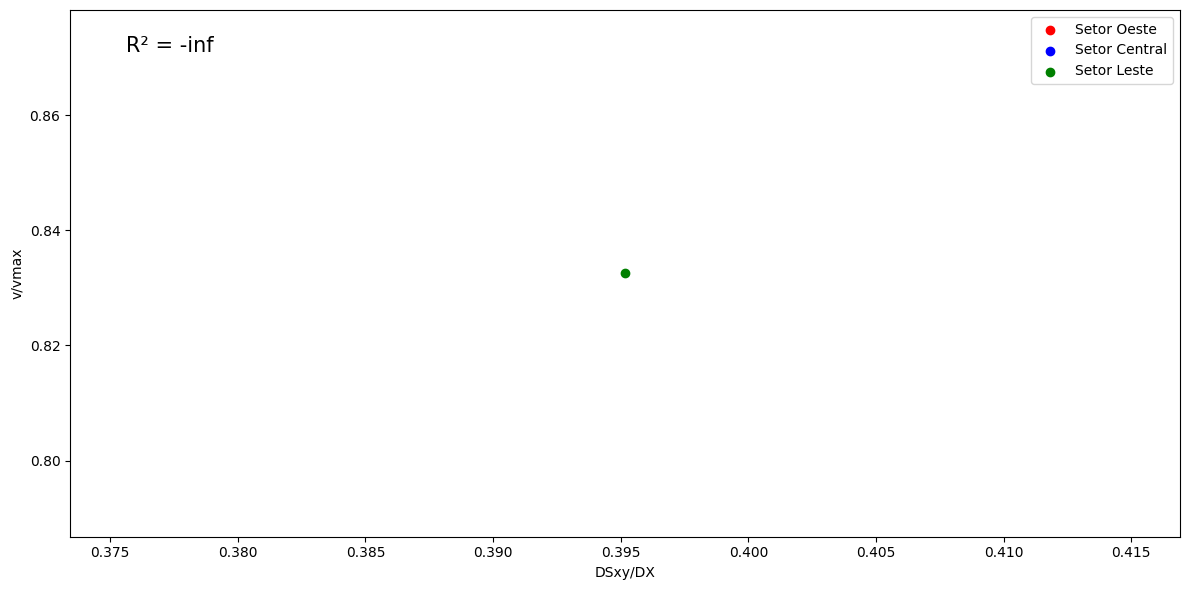

In [49]:


# --- Bloco de Visualização (Gráfico) ---
plt.figure(figsize=(12,6)) # Cria a figura do gráfico com um tamanho específico.

# plota cada variável como pontos
plt.scatter(np.abs(df_O["variacao"]), df_O["max_velocidade"], label="Setor Oeste", color="red", alpha = 1) # Plota os dados de 'var2' como pontos vermelhos.
plt.scatter(np.abs(df_C["variacao"]), df_C["max_velocidade"], label="Setor Central", color="blue", alpha = 1) # Plota os dados de 'var2' como pontos vermelhos.
plt.scatter(np.abs(df_L["variacao"]), df_L["max_velocidade"], label="Setor Leste", color="green", alpha = 1) # Plota os dados de 'var2' como pontos vermelhos.

#------------------------------------------------------------------------
#NÃO SEI MEXER, CHAT QUE FEZ
#------------------------------------------------------------------------
# linha de tendência entre var2 e velocidade máxima. 

y_clean = df_resultados["max_velocidade"].astype(float)
x_clean = np.abs(df_resultados["variacao"].astype(float))
mask = np.isfinite(x_clean) & np.isfinite(y_clean)
coef = np.polyfit(x_clean[mask], y_clean[mask], 1)
tendencia = np.poly1d(coef)
x_vals = np.linspace(x_clean[mask].min(), x_clean[mask].max(), 100)
plt.plot(x_vals, tendencia(x_vals), color="black", linewidth=2)

# cálculo do R²
y_pred = tendencia(x_clean[mask])
ss_res = np.sum((y_clean[mask] - y_pred)**2)
ss_tot = np.sum((y_clean[mask] - np.mean(y_clean[mask]))**2)
r1 = 1 - (ss_res / ss_tot)

#------------------------------------------------------------------------
#NÃO SEI MEXER, CHAT QUE FEZ
#------------------------------------------------------------------------

# coloca os nomes dos arquivos no eixo x
plt.xlabel("DSxy/DX") # Define o rótulo do eixo y.
plt.ylabel("v/vmax") # Define o rótulo do eixo x.
plt.title("") # Define o título do gráfico.
plt.legend() # Mostra a legenda (var, var2, var3).
plt.tight_layout() # Ajusta o layout para evitar que os rótulos se sobreponham.
plt.text(0.05, 0.95, f"R² = {r1:.3f}", transform=plt.gca().transAxes, fontsize=15, verticalalignment="top") 
plt.show() # Exibe o gráfico gerado.